In [1]:
# Definimos varianzas y covarianzas de ejemplo para los tres activos
var_A = 0.04  # Varianza del activo A
var_B = 0.0225  # Varianza del activo B
var_C = 0.01  # Varianza del activo C
cov_AB = 0.012  # Covarianza entre A y B
cov_AC = 0.008  # Covarianza entre A y C
cov_BC = 0.006  # Covarianza entre B y C

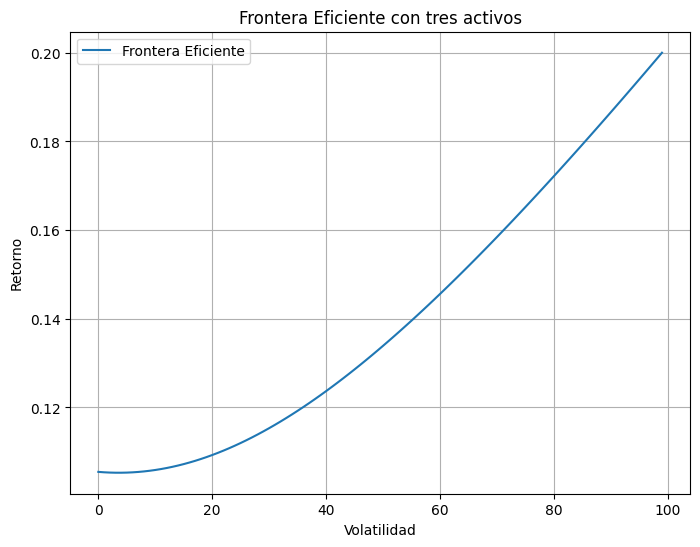

In [2]:
# contruyamos una frontera eficiente con los tres activos, variando los pesos entre 0 y 1, de forma manual y graficala


import matplotlib.pyplot as plt
import numpy as np

# definimos los pesos de los activos
pesos = np.linspace(0, 1, 100)
volatilidades = []

# calculamos la volatilidad del portafolio para cada combinación de pesos
for peso_A in pesos:
    peso_B = (1 - peso_A) / 2  # suponemos que peso_C = 1 - peso_A - peso_B
    if peso_B < 0:
        continue
    peso_C = 1 - peso_A - peso_B
    if peso_C < 0:
        continue
    
    var_portafolio = (peso_A ** 2) * var_A + (peso_B ** 2) * var_B + (peso_C ** 2) * var_C
    var_portafolio += 2 * peso_A * peso_B * cov_AB + 2 * peso_A * peso_C * cov_AC + 2 * peso_B * peso_C * cov_BC
    vol_portafolio = var_portafolio ** 0.5
    volatilidades.append(vol_portafolio)

# graficamos la frontera eficiente
plt.figure(figsize=(8,6))
plt.plot(volatilidades, label='Frontera Eficiente')
plt.xlabel('Volatilidad')
plt.ylabel('Retorno')
plt.title('Frontera Eficiente con tres activos')
plt.legend()
plt.grid(True)
plt.show()

In [3]:
# Cálculo de los pesos óptimos que minimizan la volatilidad del portafolio
from scipy.optimize import minimize

# Supongamos retornos esperados de ejemplo para los activos
retornos_esperados = np.array([0.10, 0.08, 0.06])

# Matriz de covarianza
cov_matrix = np.array([
    [var_A, cov_AB, cov_AC],
    [cov_AB, var_B, cov_BC],
    [cov_AC, cov_BC, var_C]
])

def volatilidad_portafolio(pesos, cov_matrix):
    return np.sqrt(np.dot(pesos.T, np.dot(cov_matrix, pesos)))

# Restricción: suma de pesos = 1
restriccion = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
# Límites: cada peso entre 0 y 1
limites = tuple((0, 1) for _ in range(3))
# Pesos iniciales
pesos_inicial = np.array([1/3, 1/3, 1/3])

resultado = minimize(volatilidad_portafolio, pesos_inicial, args=(cov_matrix,),
                     method='SLSQP', bounds=limites, constraints=restriccion)

pesos_optimos = resultado.x
vol_optima = volatilidad_portafolio(pesos_optimos, cov_matrix)

print('Pesos óptimos (minimizan volatilidad):', pesos_optimos)
print('Volatilidad mínima:', vol_optima)

# Comparación con un portafolio sin optimizar (pesos iguales)
pesos_iguales = np.array([1/3, 1/3, 1/3])
vol_igual = volatilidad_portafolio(pesos_iguales, cov_matrix)
print('Volatilidad con pesos iguales:', vol_igual)

Pesos óptimos (minimizan volatilidad): [0.01359653 0.18971858 0.79668489]
Volatilidad mínima: 0.09598584407613732
Volatilidad con pesos iguales: 0.11761519176251566


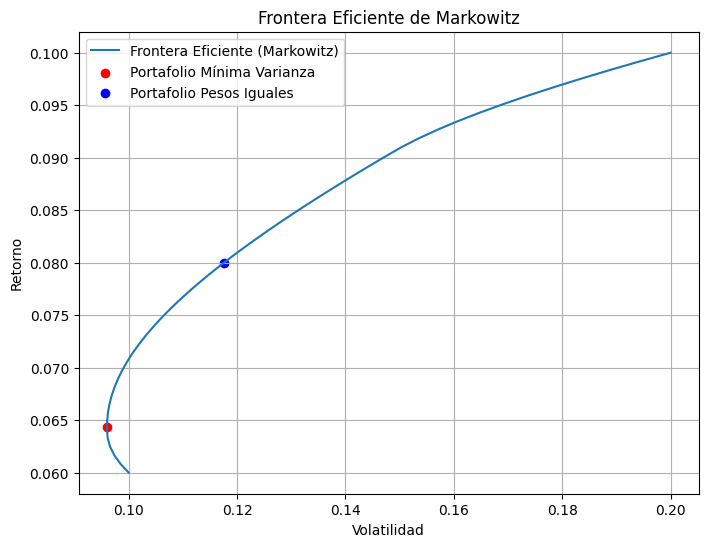

In [4]:
# Frontera eficiente con optimización de Markowitz
num_puntos = 50
retornos_objetivo = np.linspace(retornos_esperados.min(), retornos_esperados.max(), num_puntos)
vols_efficient = []
pesos_efficient = []

for r_obj in retornos_objetivo:
    restricciones = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},  # suma de pesos = 1
        {'type': 'eq', 'fun': lambda x: np.dot(x, retornos_esperados) - r_obj}  # retorno objetivo
    )
    resultado = minimize(volatilidad_portafolio, pesos_inicial, args=(cov_matrix,),
                         method='SLSQP', bounds=limites, constraints=restricciones)
    if resultado.success:
        vols_efficient.append(resultado.fun)
        pesos_efficient.append(resultado.x)
    else:
        vols_efficient.append(np.nan)
        pesos_efficient.append([np.nan, np.nan, np.nan])

# Graficar la frontera eficiente optimizada
plt.figure(figsize=(8,6))
plt.plot(vols_efficient, retornos_objetivo, label='Frontera Eficiente (Markowitz)')
plt.scatter(vol_optima, np.dot(pesos_optimos, retornos_esperados), color='red', label='Portafolio Mínima Varianza')
plt.scatter(vol_igual, np.dot(pesos_iguales, retornos_esperados), color='blue', label='Portafolio Pesos Iguales')
plt.xlabel('Volatilidad')
plt.ylabel('Retorno')
plt.title('Frontera Eficiente de Markowitz')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# Descargar datos históricos de precios de tres activos: Apple, Microsoft y Google
import yfinance as yf

tickers = ['AAPL', 'MSFT', 'GOOGL']
datos = yf.download(tickers, start='2020-01-01', end='2023-01-01')
print(datos.head())



[*********************100%***********************]  3 of 3 completed

Price           Close                              High             \
Ticker           AAPL      GOOGL        MSFT       AAPL      GOOGL   
Date                                                                 
2020-01-02  72.400490  67.920807  152.158356  72.460753  67.920807   
2020-01-03  71.696632  67.565498  150.263779  72.455950  68.172416   
2020-01-06  72.267937  69.366394  150.652145  72.306506  69.391700   
2020-01-07  71.928055  69.232391  149.278503  72.533095  69.648748   
2020-01-08  73.085121  69.725174  151.656326  73.386438  70.063120   

Price                         Low                              Open  \
Ticker            MSFT       AAPL      GOOGL        MSFT       AAPL   
Date                                                                  
2020-01-02  152.262561  71.156652  66.819630  149.989002  71.409755   
2020-01-03  151.523715  71.472454  66.860824  149.733282  71.629138   
2020-01-06  150.718465  70.568510  67.043446  148.264897  70.819208   
2020-01-07  1

In [19]:
# Extraer precios de cierre y calcular retornos logarítmicos
if ('Close' in datos.columns):
    precios = datos['Close']
else:
    # Si los datos tienen MultiIndex en columnas (por ticker y tipo de precio)
    precios = datos.xs('Close', level=1, axis=1)

# Calcular retornos logarítmicos
daily_log_returns = np.log(precios / precios.shift(1))
daily_log_returns.dropna(inplace=True)  # Eliminar filas con NaN resultantes del cálculo de retornos    
daily_log_returns.head()

Ticker,AAPL,GOOGL,MSFT
Date,,,
2020-01-03,-0.009769,-0.005245,-0.012530
2020-01-06,0.007937,0.026305,0.002581
2020-01-07,-0.004714,-0.001934,-0.009160
2020-01-08,0.015958,0.007093,0.015803
2020-01-09,0.021018,0.010443,0.012416


In [22]:
# Cálculo de la matriz de covarianza
matriz_covarianza = daily_log_returns.cov()
print("Matriz de Covarianza:")
print(matriz_covarianza)

Matriz de Covarianza:
Ticker      AAPL     GOOGL      MSFT
Ticker                              
AAPL    0.000541  0.000372  0.000415
GOOGL   0.000372  0.000474  0.000397
MSFT    0.000415  0.000397  0.000481


In [24]:
# calculo de la volatiliad del portafolio con pesos iguales
pesos_iguales = np.array([1/3, 1/3, 1/3])
vol_igual = np.sqrt(np.dot(pesos_iguales.T, np.dot(matriz_covarianza, pesos_iguales)))
print('Volatilidad con pesos iguales:', vol_igual)

Volatilidad con pesos iguales: 0.020720147789113325


In [28]:
# Calcular los pesos óptimos que minimizan la volatilidad del portafolio usando la matriz de covarianza real
from scipy.optimize import minimize

# Usar los retornos medios diarios como retornos esperados
retornos_esperados = daily_log_returns.mean().values
cov_matrix = matriz_covarianza.values
num_activos = len(retornos_esperados)

# Función objetivo: volatilidad del portafolio
def volatilidad_portafolio(pesos, cov_matrix):
    return np.sqrt(np.dot(pesos.T, np.dot(cov_matrix, pesos)))

# Restricción: suma de pesos = 1
restriccion = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
# Límites: cada peso entre 0 y 1
limites = tuple((0, 1) for _ in range(num_activos))
# Pesos iniciales
pesos_inicial = np.array([1/num_activos]*num_activos)

resultado = minimize(volatilidad_portafolio, pesos_inicial, args=(cov_matrix,),
                     method='SLSQP', bounds=limites, constraints=restriccion)

pesos_optimos = resultado.x
vol_optima = volatilidad_portafolio(pesos_optimos, cov_matrix)

print('Pesos óptimos (minimizan volatilidad):', pesos_optimos)
print('Volatilidad mínima:', vol_optima)

Pesos óptimos (minimizan volatilidad): [0.33333333 0.33333333 0.33333333]
Volatilidad mínima: 0.020720147789113325


In [ ]:
# Frontera eficiente de Markowitz (todos los portafolios óptimos) con datos reales
retornos_objetivo_real = np.linspace(retornos_esperados.min(), retornos_esperados.max(), 100)
vols_markowitz, rets_markowitz, pesos_markowitz = [], [], []

for r_obj in retornos_objetivo_real:
    restricciones = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x, r=r_obj: np.dot(x, retornos_esperados) - r}
    )
    
    resultado = minimize(
        volatilidad_portafolio,
        pesos_inicial,
        args=(cov_matrix,),
        method='SLSQP',
        bounds=limites,
        constraints=restricciones
    )
    
    if resultado.success:
        vols_markowitz.append(resultado.fun)
        rets_markowitz.append(np.dot(resultado.x, retornos_esperados))
        pesos_markowitz.append(resultado.x)

vols_markowitz = np.array(vols_markowitz)
rets_markowitz = np.array(rets_markowitz)

plt.figure(figsize=(9, 6))
plt.plot(vols_markowitz, rets_markowitz, color='gray', alpha=0.6)
sc = plt.scatter(vols_markowitz, rets_markowitz, c=rets_markowitz, cmap='viridis', s=35, label='Portafolios óptimos')

idx_min = np.argmin(vols_markowitz)
plt.scatter(vols_markowitz[idx_min], rets_markowitz[idx_min], color='red', s=90, label='Mínima varianza')

plt.xlabel('Volatilidad diaria')
plt.ylabel('Retorno esperado diario')
plt.title('Frontera eficiente de Markowitz')
plt.grid(True, alpha=0.3)
plt.legend()
plt.colorbar(sc, label='Retorno esperado')
plt.show()